In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#Importing dataframe
df = pd.read_csv('movies.csv')
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [3]:
#Understanding the dataframe strructure
print(df.dtypes)
print()
print(df.info())

name            str
rating          str
genre           str
year          int64
released        str
score       float64
votes       float64
director        str
writer          str
star            str
country         str
budget      float64
gross       float64
company         str
runtime     float64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   str    
 1   rating    7591 non-null   str    
 2   genre     7668 non-null   str    
 3   year      7668 non-null   int64  
 4   released  7666 non-null   str    
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   str    
 8   writer    7665 non-null   str    
 9   star      7667 non-null   str    
 10  country   7665 non-null   str    
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13 

In [4]:
#Changing year and release date to Date Format
df['released'] = df['released'].str.split('(').str[0].str.strip()
df['released'] = pd.to_datetime(df['released'],format='mixed')
df['year'] = pd.to_datetime(df['year'],format='%Y')


In [5]:
#Checking for null vales
df.isnull().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [6]:
#Dropping movies that has missing budgets
df = df.dropna(subset = ['budget'])
df.isnull().sum()

name         0
rating      20
genre        0
year         0
released     0
score        3
votes        3
director     0
writer       0
star         1
country      1
budget       0
gross       61
company      6
runtime      2
dtype: int64

In [7]:
#Changing year to rlease date year
df['year'] = df['released'].dt.year

year
2002    170
2011    170
2003    168
2008    168
2000    166
Name: count, dtype: int64


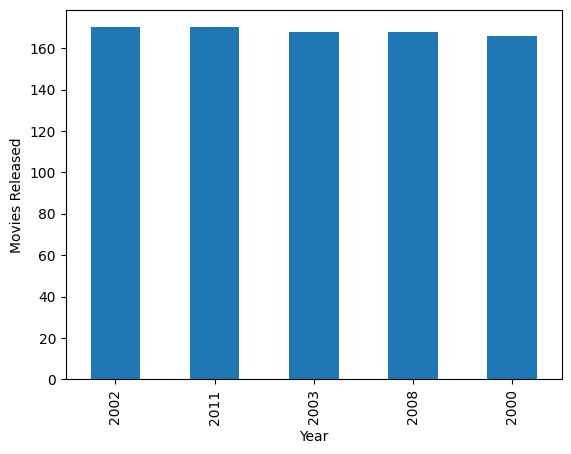

In [8]:
#Coutning the number of movies released each year
MoviesCountYear = df['year'].value_counts().head()
print(MoviesCountYear)
#Yers with the most amount of movies released
MoviesCountYear.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Movies Released')
plt.show()


“The analysis shows that movie production peaked in certain years such as 2002 and 2011, indicating periods of high industry activity.

                                            name         gross
5445                                      Avatar  2.847246e+09
7445                           Avengers: Endgame  2.797501e+09
3045                                     Titanic  2.201647e+09
6663  Star Wars: Episode VII - The Force Awakens  2.069522e+09
7244                      Avengers: Infinity War  2.048360e+09


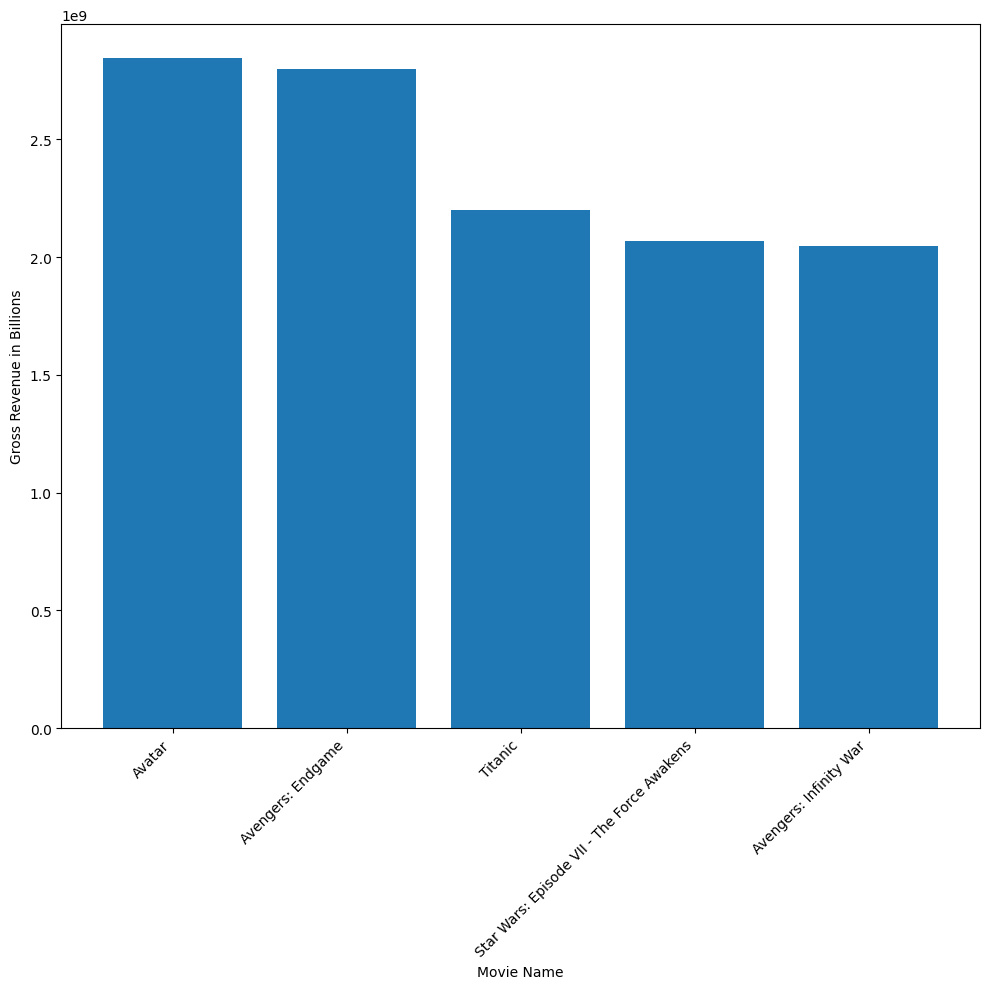

In [9]:
#Getting movies with their top 5 gross revenue
MovieGross = df.loc[:,['name','gross']].sort_values(by='gross',ascending=False).head(5)
print(MovieGross)
#A bar graph that shows the top 5 movies that earned the most revenue
plt.figure(figsize=(10,10))
plt.bar(MovieGross['name'],MovieGross['gross'])
plt.xlabel('Movie Name')
plt.ylabel('Gross Revenue in Billions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

“The top 5 highest-grossing movies each generated over $2 billion, highlighting the dominance of blockbuster franchises in driving global box office revenue.”

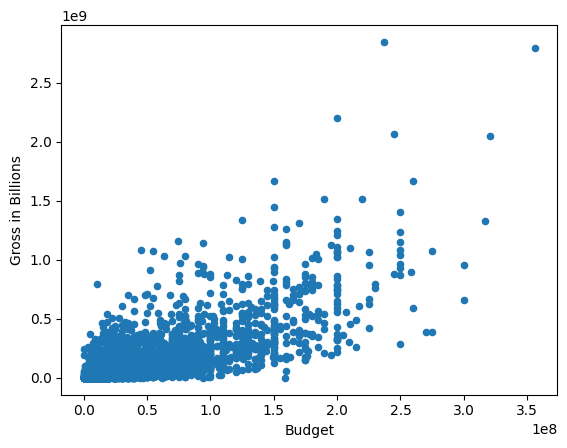

In [10]:
#Plotting a line plot to check relationship between budget and gross
df.plot.scatter(x='budget', y='gross')
plt.xlabel('Budget')
plt.ylabel('Gross in Billions')
plt.show()

“The scatter plot indicates a positive relationship between budget and gross revenue, suggesting that higher-budget films tend to generate higher earnings. However, the presence of outliers shows that large investments do not always guarantee success.”

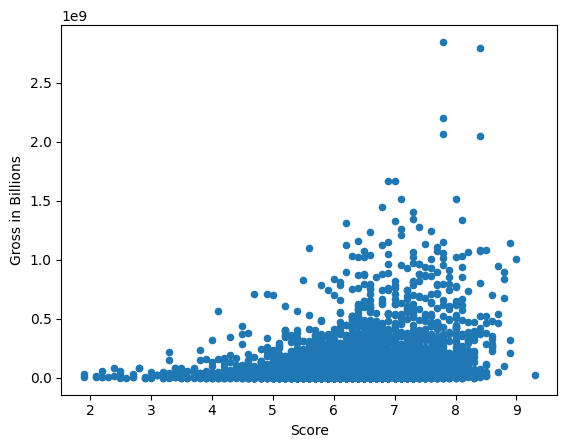

In [11]:
#Correlation between score and gross
df.plot.scatter(x='score', y='gross')
plt.xlabel('Score')
plt.ylabel('Gross in Billions')
plt.show()

“The relationship between audience score and gross revenue appears weak, indicating that highly rated movies do not necessarily achieve higher box office success.”

year
2017    2.875049e+10
2018    2.800904e+10
2019    2.744284e+10
2015    2.730540e+10
2016    2.703732e+10
Name: gross, dtype: float64


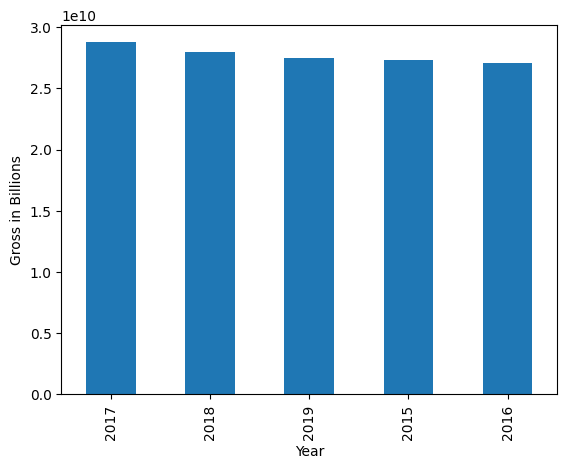

In [12]:
#Plotting the years with the top 5 revenue gained
year_rev = df.groupby('year')['gross'].sum().sort_values(ascending=False)
print(year_rev.head())
year_rev.head().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Gross in Billions')
plt.show()

“Total revenue has generally increased over time, suggesting growth in the film industry, possibly driven by globalization and higher production budgets.”

company
Warner Bros.             5.477320e+10
Universal Pictures       5.124111e+10
Columbia Pictures        4.235643e+10
Paramount Pictures       4.002170e+10
Twentieth Century Fox    3.954257e+10
Name: gross, dtype: float64


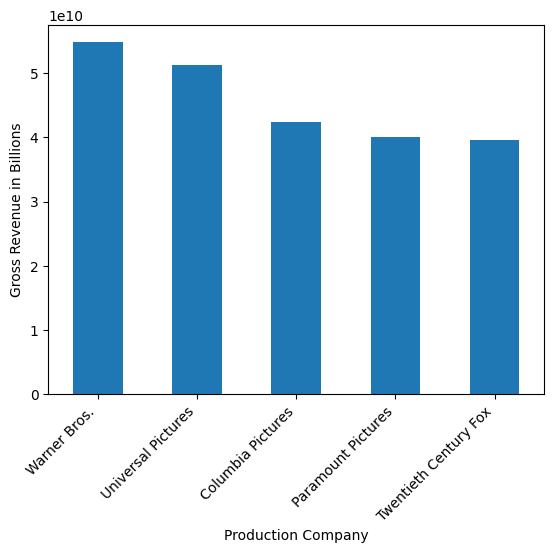

In [13]:
#Top 5Companies with the highest revenue generated
comp_rev = df.groupby('company')['gross'].sum().sort_values(ascending=False).head()
print(comp_rev)
comp_rev.plot(kind='bar')
plt.xlabel('Production Company')
plt.ylabel('Gross Revenue in Billions')
plt.xticks(rotation = 45,ha = 'right')
plt.show()


“A small number of production companies contribute significantly to total revenue, indicating a concentrated market where a few key players dominate the industry.”

genre
Action       2.377910e+11
Comedy       8.851482e+10
Animation    7.787465e+10
Drama        5.234112e+10
Adventure    4.357871e+10
Name: gross, dtype: float64


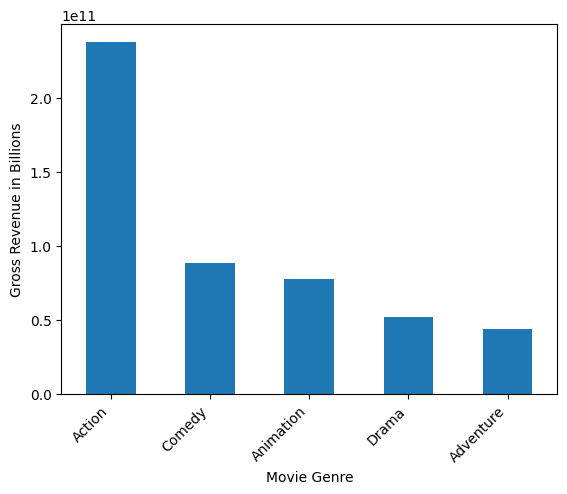

In [14]:
#Top 5 Genres in Terms of Gross Revenue
genre_rev = df.groupby('genre')['gross'].sum().sort_values(ascending=False).head()
print(genre_rev)
genre_rev.plot(kind='bar')
plt.xlabel('Movie Genre')
plt.ylabel('Gross Revenue in Billions')
plt.xticks(rotation = 45,ha = 'right')
plt.show()

“Genres such as Action and Adventure generate higher average revenue, suggesting strong audience demand for large-scale, high-production entertainment films.”

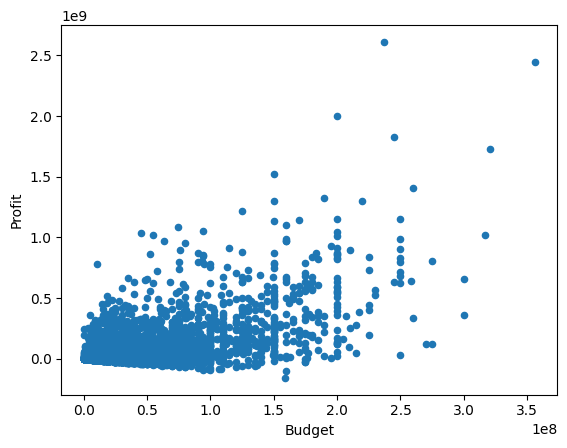

In [16]:
#Profit vs Budget Analysis
df['profit'] = df['gross'] - df['budget']
df.plot.scatter(x='budget',y='profit')
plt.xlabel('Budget')
plt.ylabel('Profit')
plt.show()

“Profit analysis shows that some films achieve high returns despite moderate budgets, indicating that efficient production and strong audience appeal can outperform sheer investment.”

Conclusion:
The analysis indicates that movie success is primarily influenced by budget and production companies, while genre and market trends also play significant roles. Although higher budgets generally lead to higher revenue, exceptions exist, and audience ratings alone are not strong predictors of financial success. Overall, the industry is driven by blockbuster films and a few dominant companies